Q1. Missing Data Identification

Scenario:
 The hospital suspects incomplete patient records.

Task:

  > Identify missing values in each column
  > Calculate percentage of missing data



```
# Q1. Missing Data Identification

import pandas as pd
df = pd.read_csv('Downloads/healthcare_data_cleaning_dataset.csv')

# Step 1: Missing values count
missing_count = df.isnull().sum()

# Step 2: Percentage of missing data
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine both in one table
missing_data_report = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage
})

print(missing_data_report)
```
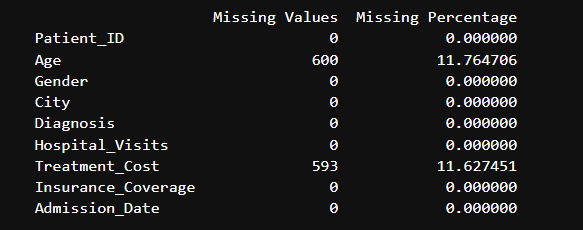

Q2. Handling Missing Age

Scenario:
 Age is critical for medical analysis, but some values are missing.

Task:

Replace missing Age values with an appropriate method

Justify your choice (mean/median)



```
#Q2. Handling Missing Age

import pandas as pd

df = pd.read_csv('Downloads/healthcare_data_cleaning_dataset.csv')
# Check skewness idea (optional but important)
print(df["Age"].skew())

df["Age"] = df["Age"].fillna(df["Age"].mean())

# If skewed data → Median (better option)

df["Age"] = df["Age"].fillna(df["Age"].median())

```
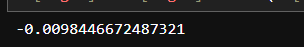

Q3. Handling Missing Treatment Cost

Scenario:
 Treatment cost is highly skewed due to expensive treatments.

Task:

Handle missing Treatment_Cost values

Choose the correct imputation method and explain why



```
Why Median is Best:

Data is highly skewed (right-skewed)

Contains outliers (very expensive treatments)

Median is robust to outliers

Gives a more realistic central value


import pandas as pd

df = pd.read_csv('Downloads/healthcare_data_cleaning_dataset.csv')
df["Treatment_Cost"] = df["Treatment_Cost"].fillna(df["Treatment_Cost"].median())
print(df.head())


missing_count = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_data_report = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage
})

print(missing_data_report)
```

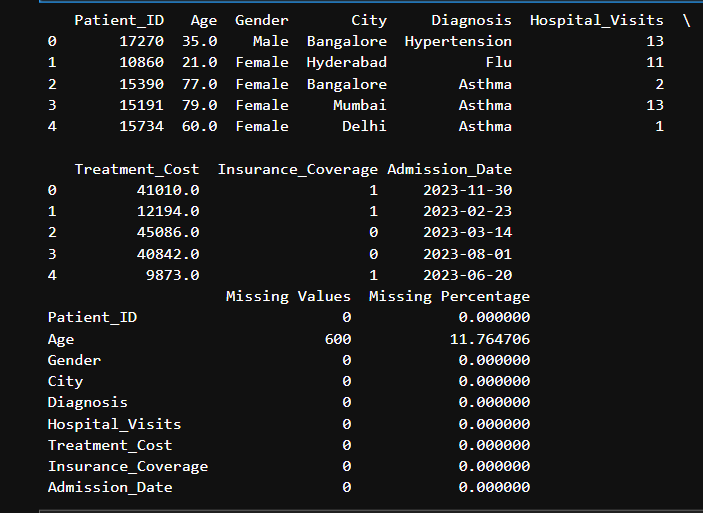


Q4. Duplicate Patient Records

Scenario:
 Some patient records were entered multiple times.

Task:

Identify duplicate rows

Remove duplicates

Compare dataset size before and after



```

# duplicate rows check
duplicates = df.duplicated()

print(duplicates.sum())

df[df.duplicated()]

df_cleaned = df.drop_duplicates()

print("Before:", df.shape)
print("After:", df_cleaned.shape)
```
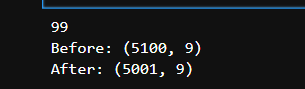

Q5. Invalid Age Values (Data Quality Check)

Scenario:
 Some patients have unrealistic age values (e.g., >100 or <0).

Task:

Detect such records

Decide whether to remove or correct them



```
invalid_age = df[(df["Age"] < 0) | (df["Age"] > 100)]

print(invalid_age)
print("Invalid records count:", invalid_age.shape[0])
```

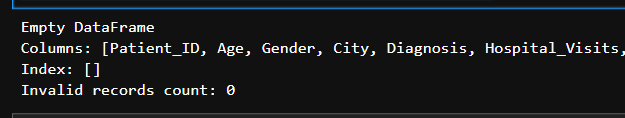

Q6. Outlier Detection (Treatment Cost)

Scenario:
 Extreme treatment costs are affecting analysis.

Task:

Detect outliers using IQR method

Display number of outliers



```

# Q1 and Q3 calculate
Q1 = df["Treatment_Cost"].quantile(0.25)
Q3 = df["Treatment_Cost"].quantile(0.75)

# IQR
IQR = Q3 - Q1

# Boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df["Treatment_Cost"] < lower_bound) |
              (df["Treatment_Cost"] > upper_bound)]

print("Number of outliers:", outliers.shape[0])

outliers
```
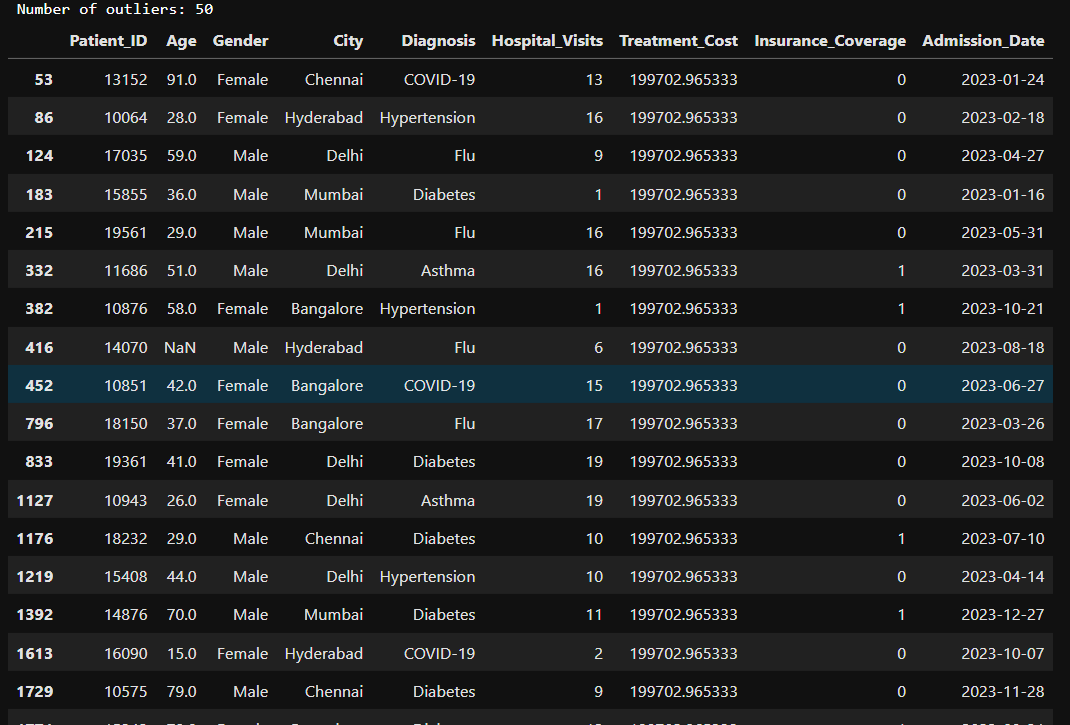


Q7. Outlier Treatment

Scenario:
The business team wants to retain all records.

Task:

Apply capping (Winsorization) on Treatment_Cost

Use 5th and 95th percentile



```
lower_cap = df["Treatment_Cost"].quantile(0.05)
upper_cap = df["Treatment_Cost"].quantile(0.95)

print("Lower cap:", lower_cap)
print("Upper cap:", upper_cap)

df["Treatment_Cost"] = df["Treatment_Cost"].apply(
    lambda x: lower_cap if x < lower_cap else upper_cap if x > upper_cap else x
)


print(df["Treatment_Cost"].describe())
```




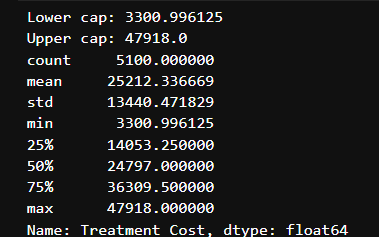


Q8. Transformation

Scenario:
 Treatment cost is highly skewed.

Task:

Apply log transformation

Create a new column

Compare before vs after distribution





```
step 1:
import numpy as np

df["Treatment_Cost_Log"] = np.log(df["Treatment_Cost"])

step 2:

print("Before Transformation:")
print(df["Treatment_Cost"].describe())

print("\nAfter Log Transformation:")
print(df["Treatment_Cost_Log"].describe())

step 3:

import matplotlib.pyplot as plt

plt.figure()

# Before
df["Treatment_Cost"].hist()
plt.title("Before Log Transformation")
plt.show()

plt.figure()

# After
df["Treatment_Cost_Log"].hist()
plt.title("After Log Transformation")
plt.show()
```
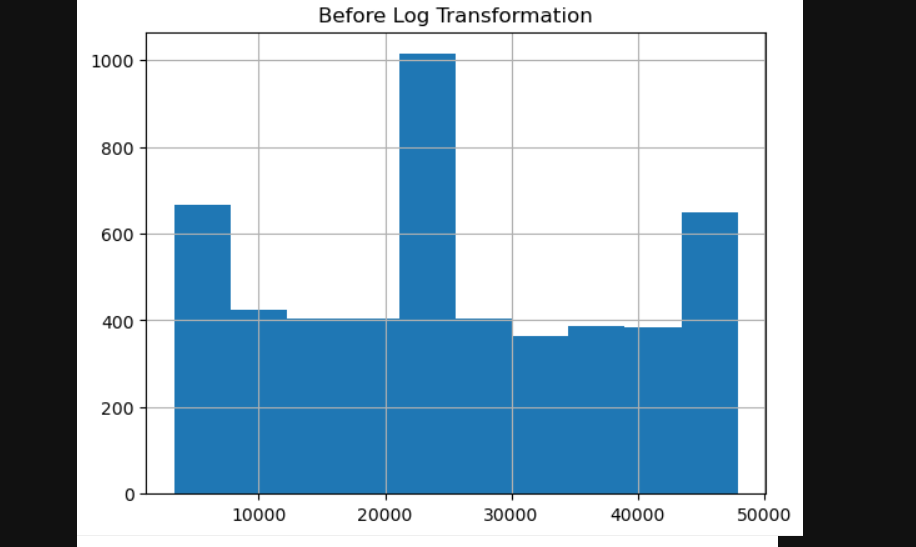


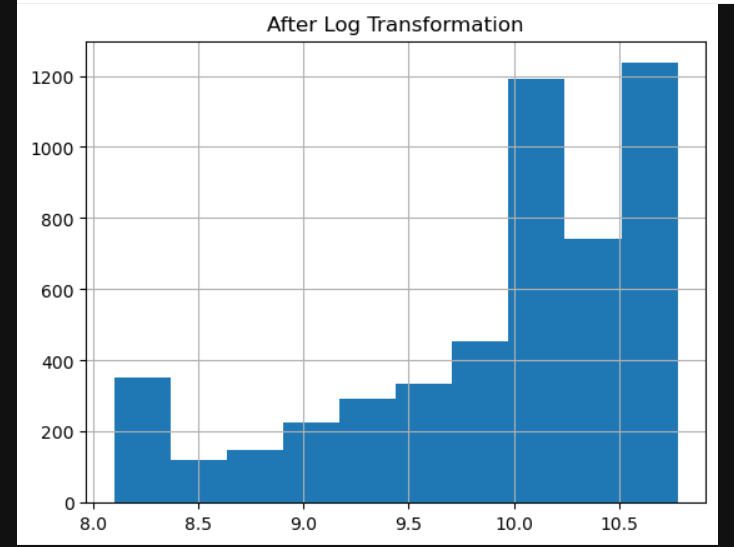


Q9. Time-Based Missing Handling

Scenario:
 Admission dates should follow a logical sequence.

Task:

Sort data by Admission_Date

Apply forward fill or backward fill where appropriate

Justify your choice





